In [1]:
import pandas as pd
#eE
# Load CSV file
df = pd.read_csv("./dataset.csv")

Define the target

In [2]:
cutoff_year = 2022
future_years = [2023, 2024]

# clients known up to the cutoff
clients_until_cutoff = set(df.loc[df["YYYY"] <= cutoff_year, "CLIENT"].unique())

# active in cutoff year
active_in_2022 = set(df.loc[df["YYYY"] == cutoff_year, "CLIENT"].unique())


# inactive at cutoff = no purchase in 2022
inactive_clients = sorted(clients_until_cutoff - active_in_2022)

# future reactivation
future_active_clients = set(df.loc[df["YYYY"].isin(future_years), "CLIENT"].unique())

target_df = pd.DataFrame({"CLIENT": inactive_clients})
target_df["target"] = target_df["CLIENT"].isin(future_active_clients).astype(int)

target_df

,CLIENT,target
0,0,1
1,1,1
2,2,0
3,3,1
4,4,1
5,5,1
6,6,0
7,7,1
8,8,1
9,9,1


we turn transaction rows into one row per client.
one row = one client

columns = features about that client

If we want to predict reactivation, we cannot feed the raw rows directly.
We need to summarize each client’s past behavior into features like:

how many purchases they made

how much they spent

what their usual category was

how recently they purchased

In [3]:
pre_df = df[df["YYYY"] <= cutoff_year].copy()

# main category per client
main_cat = (
    pre_df.groupby("CLIENT")["CAT_ECO"]
    .agg(lambda s: s.mode().iat[0])
    .reset_index()
    .rename(columns={"CAT_ECO": "main_cat_eco"})
)

client_features = (
    pre_df.groupby("CLIENT")
    .agg(
        n_txn=("PRICE", "size"),
        total_spend=("PRICE", "sum"),
        avg_price=("PRICE", "mean"),
        max_price=("PRICE", "max"),
        last_year=("YYYY", "max")
    )
    .reset_index()
)

# Main PRODUCT_TYPE per client
main_product_type = (
    pre_df.groupby("CLIENT")["PROD_TYPE"]
    .agg(lambda s: s.mode().iat[0])
    .reset_index()
    .rename(columns={"PROD_TYPE": "main_product_type"})
)

client_features["recency_2022"] = cutoff_year - client_features["last_year"]

client_features = (client_features
                                .merge(main_cat, on="CLIENT", how="left")
                                .merge(main_product_type, on="CLIENT", how="left"))
client_features

,CLIENT,n_txn,total_spend,avg_price,max_price,last_year,recency_2022,main_cat_eco,main_product_type
0,0,1,79,79.000000,79,2017,5,0,A
1,1,4,125,31.250000,51,2017,5,1,A
2,2,4,21,5.250000,9,2018,4,1,C
3,3,3,142,47.333333,60,2018,4,1,B
4,4,2,70,35.000000,45,2019,3,0,A
5,5,1,52,52.000000,52,2019,3,1,B
6,6,4,15,3.750000,7,2018,4,0,C
7,7,1,50,50.000000,50,2019,3,1,A
8,8,1,80,80.000000,80,2019,3,1,A
9,9,4,190,47.500000,80,2019,3,1,A


In [4]:
model_df = target_df.merge(client_features, on="CLIENT", how="left")
model_df

,CLIENT,target,n_txn,total_spend,avg_price,max_price,last_year,recency_2022,main_cat_eco,main_product_type
0,0,1,1,79,79.000000,79,2017,5,0,A
1,1,1,4,125,31.250000,51,2017,5,1,A
2,2,0,4,21,5.250000,9,2018,4,1,C
3,3,1,3,142,47.333333,60,2018,4,1,B
4,4,1,2,70,35.000000,45,2019,3,0,A
5,5,1,1,52,52.000000,52,2019,3,1,B
6,6,0,4,15,3.750000,7,2018,4,0,C
7,7,1,1,50,50.000000,50,2019,3,1,A
8,8,1,1,80,80.000000,80,2019,3,1,A
9,9,1,4,190,47.500000,80,2019,3,1,A


In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

X = model_df[[
    "n_txn",
    "total_spend",
    "avg_price",
    "max_price",
    "recency_2022",
    "main_cat_eco",
    "main_product_type"
]]

y = model_df["target"]


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

numeric_features = ["n_txn", "total_spend", "avg_price", "max_price", "recency_2022"]
categorical_features = ["main_cat_eco"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

clf = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

clf.fit(X_train, y_train)

X_train shape: (10, 7)
X_test shape : (3, 7)
y_train shape: (10,)
y_test shape : (3,)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['n_txn', 'total_spend',
                                                   'avg_price', 'max_price',
                                                   'recency_2022']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['main_cat_eco'])])),
                ('model', LogisticRegression(max_iter=1000))])

In [59]:
model_df["proba_reactivate"] = clf.predict_proba(X)[:, 1]
model_df = model_df.sort_values("proba_reactivate", ascending=False)

model_df[["CLIENT", "target", "proba_reactivate", "n_txn", "total_spend", "recency_2022", "main_cat_eco","main_product_type"]]

,CLIENT,target,proba_reactivate,n_txn,total_spend,recency_2022,main_cat_eco,main_product_type
8,8,1,0.988041,1,80,3,1,A
0,0,1,0.980919,1,79,5,0,A
9,9,1,0.979185,4,190,3,1,A
11,11,1,0.979072,4,203,5,1,A
3,3,1,0.947739,3,142,4,1,B
5,5,1,0.932212,1,52,3,1,B
7,7,1,0.923656,1,50,3,1,A
4,4,1,0.862074,2,70,3,0,A
1,1,1,0.815698,4,125,5,1,A
10,10,0,0.245564,4,23,3,1,C


In [6]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

tst  = False

if (tst):
    y_pred = clf.predict(X_test)
    y_proba = clf.predict_proba(X_test)[:, 1]

    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred, zero_division=0))
    print("Recall   :", recall_score(y_test, y_pred, zero_division=0))
    print("F1-score :", f1_score(y_test, y_pred, zero_division=0))
    print("AUC      :", roc_auc_score(y_test, y_proba))

    print("\nConfusion matrix:")
    print(confusion_matrix(y_test, y_pred))
else:
    # Predictions
    y_pred = clf.predict(X)
    y_proba = clf.predict_proba(X)[:, 1]

    # Metrics
    print("Accuracy :", accuracy_score(y, y_pred))
    print("Precision:", precision_score(y, y_pred, zero_division=0))
    print("Recall   :", recall_score(y, y_pred, zero_division=0))
    print("F1-score :", f1_score(y, y_pred, zero_division=0))
    print("AUC      :", roc_auc_score(y, y_proba))

    print("\nConfusion matrix:")
    print(confusion_matrix(y, y_pred))

    print("\nClassification report:")
    print(classification_report(y, y_pred, zero_division=0))

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-score : 1.0
AUC      : 1.0

Confusion matrix:
[[4 0]
 [0 9]]

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      1.00      1.00         9

    accuracy                           1.00        13
   macro avg       1.00      1.00      1.00        13
weighted avg       1.00      1.00      1.00        13



<Figure size 800x600 with 0 Axes>

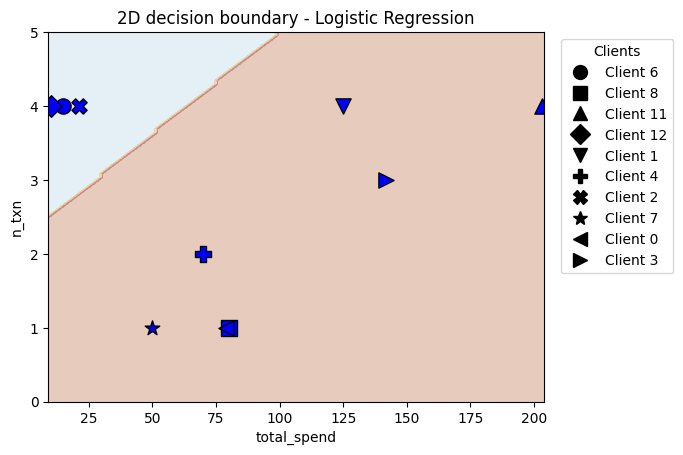

In [7]:
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import DecisionBoundaryDisplay
from matplotlib.lines import Line2D

# choose 2 numeric features
feat1 = "total_spend"
feat2 = "n_txn"

X_2d = model_df[[feat1, feat2]]
y = model_df["target"]
client_ids = model_df["CLIENT"].values

X_train, X_test, y_train, y_test, client_train, client_test = train_test_split(
    X_2d,
    y,
    client_ids,
    test_size=0.2,
    random_state=42,
    stratify=y
)

clf_2d = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

clf_2d.fit(X_train, y_train)

plt.figure(figsize=(8, 6))

# DecisionBoundaryDisplay.from_estimator(
#     clf_2d,
#     X_train,
#     response_method="predict_proba",
#     class_of_interest=1,
#     cmap=plt.cm.RdBu,
#     alpha=0.35
# )

DecisionBoundaryDisplay.from_estimator(
    clf_2d,
    X_train,
    response_method="predict",
    cmap=plt.cm.Paired,
    alpha=0.3
)

markers = ['o', 's', '^', 'D', 'v', 'P', 'X', '*', '<', '>', 'h', '8']

legend_handles = []

# plot one point per client, with a marker tied to that client
for i, (idx, row) in enumerate(X_train.reset_index(drop=True).iterrows()):
    marker = markers[i % len(markers)]
    client = client_train[i]
    cls = y_train.iloc[i]

    plt.scatter(
        row[feat1],
        row[feat2],
        marker=marker,
        c=[cls],          # color still shows class 0/1
        cmap=plt.cm.bwr,
        edgecolor="k",
        s=120
    )

    legend_handles.append(
        Line2D(
            [0], [0],
            marker=marker,
            color="w",
            markerfacecolor="black",
            markeredgecolor="k",
            markersize=10,
            linestyle="None",
            label=f"Client {client}"
        )
    )

plt.xlabel(feat1)
plt.ylabel(feat2)
plt.title("2D decision boundary - Logistic Regression")
plt.legend(
    handles=legend_handles,
    title="Clients",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.show()